### An example, bootstrapping modeled NAO indices to produce single member samples

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import matplotlib.pyplot as plt

from rossby_utils import bootstrap_utils as boot
from rossby_utils import plothisto_utils as histo

### Reading in the data

In [14]:
era5 = xr.open_dataset(
    "/glade/campaign/cgd/cas/islas/python_savs/rossbypalooza26/processing/ERA5/ERA5_monthly_slp_1993_2025.nc").slp
cesm2_ERA5_l32 = xr.open_dataset(
    "/glade/campaign/cgd/cas/islas/python_savs/rossbypalooza26/processing/CESM2/SMYLE_ERA_L32/CESM2_SMYLE_ERA5_L32slp_1993_2020.nc").slp
cesm2_JRA_l32 = xr.open_dataset(
    "/glade/campaign/cgd/cas/islas/python_savs/rossbypalooza26/processing/CESM2/SMYLE_JRA_L32/CESM2_SMYLE_JRA_L32slp_1993_2022.nc").slp
cesm2_ERA5_l83 = xr.open_dataset(
    "/glade/campaign/cgd/cas/islas/python_savs/rossbypalooza26/processing/CESM2/SMYLE_ERA_L83/CESM2_SMYLE_ERA5_L83slp_1993_2020.nc").slp

### Selecting only years 1993 - 2016

In [15]:
era5 = era5.sel(year=slice(1993,2016))
cesm2_ERA5_l32 = cesm2_ERA5_l32.sel(year=slice(1993,2016))
cesm2_JRA_l32 = cesm2_JRA_l32.sel(year=slice(1993,2016))
cesm2_ERA5_l83 = cesm2_ERA5_l83.sel(year=slice(1993,2016))

In [19]:
cesm2_ERA5_l32['member'] = np.arange(1,20+1,1)
cesm2_JRA_l32['member'] = np.arange(21,40+1,1)
cesm2_ERA5_l83['member'] = np.arange(41,60+1,1)

cesm2 = xr.concat([cesm2_ERA5_l32, cesm2_JRA_l32, cesm2_ERA5_l83], dim='member')

### Calculating the station based NAO

In [21]:
### Remove the lead dependent climatology
era5_anoms = era5 - era5.mean('year')
cesm2_anoms = cesm2 - cesm2.mean('year')

### Normalize each month by its standard deviation
era5_norm = era5_anoms / era5_anoms.std('year')
cesm2_norm = cesm2_anoms / cesm2_anoms.std('year')

### 
# Iceland lon and lat 
lon_ice = 360 - 21.9 ; lat_ice = 64.1
# Azores lon and lat
lon_az = 360 - 28 ; lat_az = 39.5

era5_nao = era5_norm.sel(lon=lon_az, lat=lat_az, method='nearest') - era5_norm.sel(lon=lon_ice, lat=lat_ice, method='nearest')
cesm2_nao = cesm2_norm.sel(lon=lon_az, lat=lat_az, method='nearest') - cesm2_norm.sel(lon=lon_ice, lat=lat_ice, method='nearest')

era5_nao_djf = era5_nao.isel(lead=slice(1,4)).mean('lead')
cesm2_nao_djf = cesm2_nao.isel(lead=slice(1,4)).mean('lead')

era5_nao_djf = era5_nao_djf.compute()
cesm2_nao_djf = cesm2_nao_djf.compute()

### Bootstrapped samples of the modeled NAO

In [28]:
boot_nao_1mem = []
boot_nao_Nmem = []
for iyear in np.arange(0,cesm2_nao_djf.year.size,1): # Loop over years

    # Use the bootstrapping function in ./rossby_utils/bootstra_utils.py to randomly sample 1000 members for this year
    # This is using iyear for the random number seed so that the random number seed will be different for each year
    # The resulting array is is a one dimensional array of length 1000 (or nboots)

    # 1 member sample equivalent to observations
    boot_temp_1mem = boot.bootgen(cesm2_nao_djf.isel(year=iyear), nsamples=1, seed=iyear, nboots=1000).isel(isample=0)

    # drop the chosen members from what you sample from next - PLACEHOLDER 

    # 60 member sample
    boot_temp_Nmem = boot.bootgen(cesm2_nao_djf.isel(year=iyear), nsamples=cesm2.member.size, seed = iyear+100, nboots=1000)
    
    # append the bootstrapped array to boot_nao which will eventually contain the bootstrapped arrays for all members
    boot_nao_1mem.append(boot_temp_1mem)
    boot_nao_Nmem.append(boot_temp_Nmem)

# Concatenate the list of arrays to give an array of the form (year, nboots)
boot_nao_1mem = xr.concat(boot_nao_1mem, dim=cesm2_nao_djf.year)
boot_nao_Nmem = xr.concat(boot_nao_Nmem, dim=cesm2_nao_djf.year)

In [30]:
from rossby_utils import modeleval_utils as modeval

In [ ]:
# Compute the RPC, treating boot_nao_1mem like the observations and boot_nao_Nmem like the model ensemble

In [34]:
# Rename isample to M to to work with the default rpc code
boot_nao_Nmem = boot_nao_Nmem.rename({'isample':'M'})

In [ ]:
# Compute the RPC for each iboot using boottrapped model means

In [35]:
rpc, num, denom = modeval.compute_rpc_eade(boot_nao_Nmem, boot_nao_Nmem.mean('M'), boot_nao_1mem, timeaxis='year')

In [ ]:
# Here not using the bootstrapped model ensemble but just using the original

In [41]:
rpc_EMorig, num, denom = modeval.compute_rpc_eade(cesm2_nao_djf, cesm2_nao_djf.mean('M'), boot_nao_1mem, timeaxis='year')

In [ ]:
# Now you have 1000 values of rpc for the modeled sampled like the obs

In [38]:
# Now computing the rpc for the actual obs
cesm2_nao_djf = cesm2_nao_djf.rename({'member':'M'})
rpc_obs, num_obs, denom_obs = modeval.compute_rpc_eade(cesm2_nao_djf, cesm2_nao_djf.mean('M'), era5_nao_djf, timeaxis='year')

In [ ]:
### Compare the single member RPC distribution from the model with the observed RPC

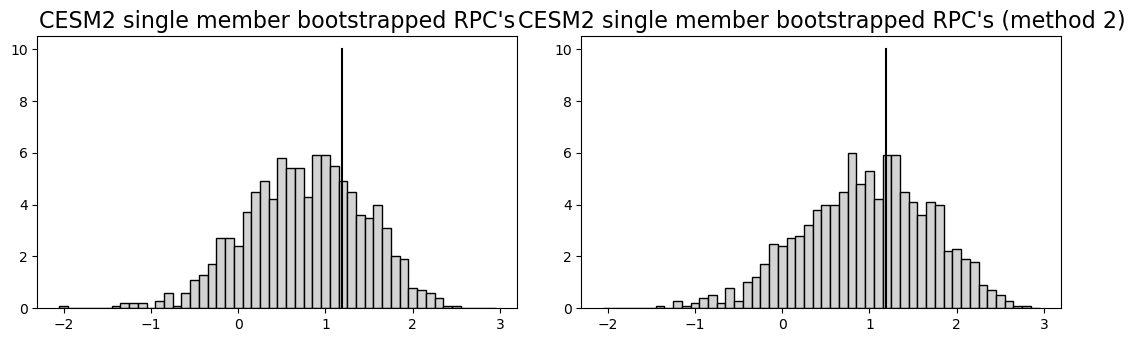

In [42]:
fig = plt.figure(figsize=(16,16))

ax = histo.plothisto(fig, rpc,np.arange(-2,3.1,0.1),0.02,0.32,0.8,0.97, 
                     percent=True, title="CESM2 single member bootstrapped RPC's")
ax.plot([rpc_obs, rpc_obs],[0,10], color='black')


ax = histo.plothisto(fig, rpc_EMorig,np.arange(-2,3.1,0.1),0.36,0.66,0.8,0.97, 
                     percent=True, title="CESM2 single member bootstrapped RPC's (method 2)")
ax.plot([rpc_obs, rpc_obs],[0,10], color='black')
